# 02 - ML Pipeline Multiclass

Full model selection and fine-tuning, OOD evaluation, and interpretability
for WoT and Dota at 3-class granularity — chosen in 01_granularity_experiment.ipynb.

In [18]:
# imports
import warnings, json
from pathlib import Path
warnings.filterwarnings('ignore')
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report
from sklearn.calibration import CalibratedClassifierCV

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from optuna.samplers import TPESampler
import joblib

import sys
sys.path.insert(0, str(Path('../..')))
from src.tokenizer import tokenize
from src.scoring import cv_score, holdout_score, ood_score, make_f1_scorer

# project root and data paths
PROJECT_ROOT = Path().resolve().parents[1]
DATA_WOT     = PROJECT_ROOT / 'data/processed_data/wot'
DATA_DOTA    = PROJECT_ROOT / 'data/processed_data/dota'

# split name -> parquet filename
_SPLIT = {'train': 'x_train.parquet', 'val': 'x_validation.parquet'}

# data loaders — replacing src.loaders
def load_wot(split): return pd.read_parquet(DATA_WOT  / _SPLIT[split])
def load_dota(split): return pd.read_parquet(DATA_DOTA / _SPLIT[split])

# TF-IDF config — consistent with cleaning pipeline
TFIDF_KWARGS = dict(
    ngram_range=(1, 2), min_df=1, max_df=0.95,
    sublinear_tf=True, norm='l2',
    analyzer='word', tokenizer=tokenize, token_pattern=None,
)

# pipeline builder — replacing src.pipelines.build_pipe
def build_pipe(clf, oversampler=None):
    steps = [('tfidf', TfidfVectorizer(**TFIDF_KWARGS))]
    if oversampler is not None:
        steps.append(('oversample', oversampler))
    steps.append(('clf', clf))
    return ImbPipeline(steps)

# reproducibility and run config
seed = 7524
OPTUNA_TRIALS = 50
MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR_MULTICLASS = Path('../../models/multi')
MODELS_DIR_MULTICLASS.mkdir(exist_ok=True)

np.random.seed(seed)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
MODELS_DIR.mkdir(exist_ok=True)

# best granularity from notebook 01
wot_best_n  = 3
dota_best_n = 3

# label schemes — 3-class: 0=Non-Toxic, 1=Mild, 2=Severe
WOT_SCHEME_3  = {0: 0, 1: 1, 2: 1, 3: 2, 4: 2, 5: 2}
DOTA_SCHEME_3 = {0: 0, 1: 2, 2: 2, 3: 1}

# combined loader — applies per-game scheme before concat
def load_combined_3class(split):
    wot  = load_wot(split).copy();  wot['label']  = wot['label'].astype(int).map(WOT_SCHEME_3)
    dota = load_dota(split).copy(); dota['label'] = dota['label'].astype(int).map(DOTA_SCHEME_3)
    return pd.concat([wot, dota], ignore_index=True)

# class name maps for plots and reports
WOT_CLASS_NAMES = {
    3: ['Non-Toxic', 'Mild Toxicity', 'Severe Toxicity'],
}

DOTA_CLASS_NAMES = {
    3: ['Non-Toxic', 'Mild Toxicity', 'Severe Toxicity'],
}

**World of Tanks**
| Class | Terminology |
|---|---|
| 0 | Non-Toxic |
| 1 | Insults and Flaming |
| 2 | Other Offensive Texts |
| 3 | Hate and Harassment |
| 4 | Threats |
| 5 | Extremism |

**Dota**
| Class | Label |
|---|---|
| 0 | Other (non-toxic) |
| 1 | Ego |
| 2 | Aggression |
| 3 | Impolite |


## Section 2: Model Selection

In [28]:
# model selection with Optuna tuning
# 50 Optuna trials = 50 sampled hyperparameter configurations
# each trial is evaluated with cross-validation on macro F1
# Optuna runs sequentially; CV can use all cores

def _macro_f1_cv(pipe, X_train, y_train):
    # macro F1 because this is multiclass classification
    return cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=make_f1_scorer(len(pd.Series(y_train).unique())),
        n_jobs=-1
    ).mean()


def _build_lr_from_trial(trial):
    # only multiclass-safe solvers
    solver = trial.suggest_categorical('clf__solver', ['lbfgs', 'newton-cg', 'saga'])
    C = trial.suggest_float('clf__C', 1e-2, 20.0, log=True)
    tol = trial.suggest_float('clf__tol', 1e-5, 1e-2, log=True)
    fit_intercept = trial.suggest_categorical('clf__fit_intercept', [True, False])

    # penalty depends on solver compatibility
    penalty = (
        'l2'
        if solver in ['lbfgs', 'newton-cg']
        else trial.suggest_categorical('clf__penalty', ['l1', 'l2'])
    )

    return LogisticRegression(
        C=C,
        solver=solver,
        penalty=penalty,
        tol=tol,
        fit_intercept=fit_intercept,
        max_iter=2000,
        random_state=seed,
        class_weight='balanced',
        n_jobs=1 if solver == 'saga' else None,
    )


def _build_svc_from_trial(trial):
    # focus on the combinations that matter and are valid
    loss = trial.suggest_categorical('clf__loss', ['hinge', 'squared_hinge'])
    C = trial.suggest_float('clf__C', 1e-2, 20.0, log=True)
    tol = trial.suggest_float('clf__tol', 1e-5, 1e-2, log=True)
    fit_intercept = trial.suggest_categorical('clf__fit_intercept', [True, False])

    # hinge requires dual=True; squared_hinge can use either
    dual = True if loss == 'hinge' else trial.suggest_categorical('clf__dual', [True, False])

    return LinearSVC(
        C=C,
        loss=loss,
        dual=dual,
        tol=tol,
        fit_intercept=fit_intercept,
        max_iter=2000,
        random_state=seed,
        class_weight='balanced',
    )

def fit_pipes_on_full_train(pipes, load_fn, scheme=None):
    train_df = load_fn('train').copy()
    if scheme is not None:
        train_df['label'] = train_df['label'].astype(int).map(scheme)

    X_train = train_df['message']
    y_train = train_df['label']

    fitted_pipes = {}
    for model_name, pipe in pipes.items():
        fitted_pipe = clone(pipe)
        fitted_pipe.fit(X_train, y_train)
        fitted_pipes[model_name] = fitted_pipe

    return fitted_pipe

def append_model_result(section, model_name, pipe, scores, study):
    # keep old models, add new one
    section['pipes'][model_name] = pipe
    section['studies'][model_name] = study

    new_row = pd.DataFrame([{'Model': model_name, **scores}])
    section['compare_df'] = (
        pd.concat([section['compare_df'], new_row], ignore_index=True)
        .drop_duplicates(subset=['Model'], keep='last')
        .sort_values('cv_f1', ascending=False)
        .reset_index(drop=True)
    )

    section['best_model_name'] = section['compare_df'].iloc[0]['Model']

def _run_optuna_search(game, model_name, model_builder, X_train, y_train):
    print(f'[{game}] {model_name} (Optuna) - {OPTUNA_TRIALS} trials ...')

    def objective(trial):
        # build a fresh pipeline for each sampled trial
        pipe = build_pipe(model_builder(trial), oversampler=None)
        return _macro_f1_cv(pipe, X_train, y_train)

    def _trial_callback(study, trial):
        # print only the current trial summary
        marker = ' *' if trial.number == study.best_trial.number else ''
        params_str = ', '.join(f"{k.split('__')[-1]}={v}" for k, v in trial.params.items())
        print(f'  [{trial.number + 1:>2}/{OPTUNA_TRIALS}]  {params_str}  f1={trial.value:.4f}{marker}')

    study = optuna.create_study(
        direction='maximize',
        sampler=TPESampler(seed=seed)
    )
    study.optimize(
        objective,
        n_trials=OPTUNA_TRIALS,
        callbacks=[_trial_callback],
        show_progress_bar=True
    )

    print(f'  -> best params={study.best_params}  f1={study.best_value:.4f}')

    # rebuild the best pipeline from the winning trial
    best_pipe = build_pipe(model_builder(study.best_trial), oversampler=None)
    best_scores = cv_score(best_pipe, X_train, y_train, cv=cv)

    return best_pipe, best_scores, study


def run_model_selection(game: str, load_fn, scheme: dict | None = None):
    # apply label scheme; None means labels are already mapped
    train_df = load_fn('train').copy()
    if scheme is not None:
        train_df['label'] = train_df['label'].astype(int).map(scheme)

    # features and labels
    X_train = train_df['message']
    y_train = train_df['label']

    models_comparison = []
    studies = {}

    # Logistic Regression — Optuna tunes regularisation + solver behaviour
    lr_pipe, lr_scores, lr_study = _run_optuna_search(
        game, 'Logistic Regression', _build_lr_from_trial, X_train, y_train
    )
    models_comparison.append({'Model': 'Logistic Regression', **lr_scores})
    studies['Logistic Regression'] = lr_study

    # LinearSVC — Optuna tunes regularisation + margin solver behaviour
    svc_pipe, svc_scores, svc_study = _run_optuna_search(
        game, 'LinearSVC', _build_svc_from_trial, X_train, y_train
    )
    models_comparison.append({'Model': 'LinearSVC', **svc_scores})
    studies['LinearSVC'] = svc_study

    compare_df = (
        pd.DataFrame(models_comparison)
        .sort_values('cv_f1', ascending=False)
        .reset_index(drop=True)
    )

    print(f'\n{game} results:')
    for _, row in compare_df.iterrows():
        print(
            f"  {row['Model']:<30}  F1={row['cv_f1']:.4f} ±{row['cv_f1_std']:.4f}"
            f"  Recall={row['cv_recall']:.4f}  Precision={row['cv_precision']:.4f}"
        )

    pipes = {
        'Logistic Regression': lr_pipe,
        'LinearSVC': svc_pipe,
    }
    return compare_df, pipes, studies

def _build_calibrated_pipe_from_saved_pipe(saved_pipe, method, ensemble):
    calibrated_pipe = clone(saved_pipe)
    base_clf = clone(calibrated_pipe.named_steps['clf'])

    calibrated_pipe.set_params(
        clf=CalibratedClassifierCV(
            estimator=base_clf,
            method=method,
            cv=cv,
            ensemble=ensemble,
        )
    )
    return calibrated_pipe

def _run_calibration_only_optuna(game, model_name, saved_pipe, X_train, y_train, n_trials=8):
    print(f'[{game}] {model_name} calibration-only Optuna - {n_trials} trials ...')

    def objective(trial):
        method = trial.suggest_categorical('clf__method', ['sigmoid', 'isotonic'])
        ensemble = trial.suggest_categorical('clf__ensemble', [True, False])

        pipe = _build_calibrated_pipe_from_saved_pipe(
            saved_pipe,
            method=method,
            ensemble=ensemble,
        )
        return _macro_f1_cv(pipe, X_train, y_train)

    study = optuna.create_study(
        direction='maximize',
        sampler=TPESampler(seed=seed)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best_method = study.best_params['clf__method']
    best_ensemble = study.best_params['clf__ensemble']

    best_pipe = _build_calibrated_pipe_from_saved_pipe(
        saved_pipe,
        method=best_method,
        ensemble=best_ensemble,
    )
    best_scores = cv_score(best_pipe, X_train, y_train, cv=cv)

    return best_pipe, best_scores, study

In [48]:
# best model selection for world of tanks dataset
print('=== WoT model selection ===')
wot_compare_df, wot_pipes, wot_studies = run_model_selection('WoT', load_wot, WOT_SCHEME_3)

# best model selection for dota dataset
print('\n=== Dota model selection ===')
dota_compare_df, dota_pipes, dota_studies = run_model_selection('Dota', load_dota, DOTA_SCHEME_3)

# model selection for combined dataset with 3-class scheme
combined_compare_df, combined_pipes, combined_studies = run_model_selection(
    'Combined', load_combined_3class, scheme=None
)

# comparison tables 
print('\nWoT comparison:')
print(wot_compare_df.to_string(index=False))
print('\nDota comparison:')
print(dota_compare_df.to_string(index=False))
print('\nCombined comparison:')
print(combined_compare_df.to_string(index=False))

=== WoT model selection ===
[WoT] Logistic Regression (Optuna) - 50 trials ...


  0%|          | 0/50 [00:00<?, ?it/s]

  [ 1/50]  solver=saga, C=0.023782084460027744, tol=0.004225527207190311, fit_intercept=False, penalty=l1  f1=0.5524 *
  [ 2/50]  solver=newton-cg, C=0.013204902347993213, tol=0.0002045184669277881, fit_intercept=True  f1=0.6696 *
  [ 3/50]  solver=newton-cg, C=0.010783421319909378, tol=0.001126202647115956, fit_intercept=True  f1=0.6649
  [ 4/50]  solver=saga, C=0.013700788552124527, tol=0.00012891649159136305, fit_intercept=True, penalty=l1  f1=0.1967
  [ 5/50]  solver=saga, C=0.09686115680990609, tol=9.084508579841047e-05, fit_intercept=True, penalty=l2  f1=0.5041
  [ 6/50]  solver=newton-cg, C=0.08530587646022501, tol=3.6592031194784106e-05, fit_intercept=False  f1=0.6567
  [ 7/50]  solver=newton-cg, C=0.09478023262442258, tol=0.00035932147966983126, fit_intercept=False  f1=0.6574
  [ 8/50]  solver=saga, C=0.21109177298212853, tol=0.0011894652761041307, fit_intercept=False, penalty=l1  f1=0.6274
  [ 9/50]  solver=saga, C=0.44938994071753774, tol=0.0003753212733438789, fit_intercept

  0%|          | 0/50 [00:00<?, ?it/s]

  [ 1/50]  loss=squared_hinge, C=2.206348934487919, tol=2.1975494341194843e-05, fit_intercept=True, dual=True  f1=0.7398 *
  [ 2/50]  loss=hinge, C=5.561907164161451, tol=0.0013826534026733321, fit_intercept=False  f1=0.7372
  [ 3/50]  loss=hinge, C=1.1948658302363075, tol=0.0062909624233258975, fit_intercept=True  f1=0.7458 *
  [ 4/50]  loss=squared_hinge, C=0.10395236453529981, tol=0.000494407675904373, fit_intercept=False, dual=False  f1=0.7253
  [ 5/50]  loss=hinge, C=9.79771321163768, tol=0.0003987676320279228, fit_intercept=True  f1=0.7492 *
  [ 6/50]  loss=hinge, C=0.11336019878531085, tol=0.002652191858059427, fit_intercept=True  f1=0.6828
  [ 7/50]  loss=squared_hinge, C=13.285201463073726, tol=0.0012090430913421174, fit_intercept=True, dual=False  f1=0.7386
  [ 8/50]  loss=squared_hinge, C=0.2418070869211729, tol=7.720549166975152e-05, fit_intercept=True, dual=True  f1=0.7398
  [ 9/50]  loss=squared_hinge, C=0.21109177298212853, tol=0.0011894652761041307, fit_intercept=False,

...

  [ 1/50]  loss=squared_hinge, C=2.206348934487919, tol=2.1975494341194843e-05, fit_intercept=True, dual=True  f1=0.8800 *
  [ 2/50]  loss=hinge, C=5.561907164161451, tol=0.0013826534026733321, fit_intercept=False  f1=0.8625
  [ 3/50]  loss=hinge, C=1.1948658302363075, tol=0.0062909624233258975, fit_intercept=True  f1=0.8849 *
  [ 4/50]  loss=squared_hinge, C=0.10395236453529981, tol=0.000494407675904373, fit_intercept=False, dual=False  f1=0.8536
  [ 5/50]  loss=hinge, C=9.79771321163768, tol=0.0003987676320279228, fit_intercept=True  f1=0.8735
  [ 6/50]  loss=hinge, C=0.11336019878531085, tol=0.002652191858059427, fit_intercept=True  f1=0.8456
  [ 7/50]  loss=squared_hinge, C=13.285201463073726, tol=0.0012090430913421174, fit_intercept=True, dual=False  f1=0.8719
  [ 8/50]  loss=squared_hinge, C=0.2418070869211729, tol=7.720549166975152e-05, fit_intercept=True, dual=True  f1=0.8826
  [ 9/50]  loss=squared_hinge, C=0.21109177298212853, tol=0.0011894652761041307, fit_intercept=False, d

  0%|          | 0/50 [00:00<?, ?it/s]

  [ 1/50]  solver=saga, C=0.023782084460027744, tol=0.004225527207190311, fit_intercept=False, penalty=l1  f1=0.6731 *
  [ 2/50]  solver=newton-cg, C=0.013204902347993213, tol=0.0002045184669277881, fit_intercept=True  f1=0.7215 *
  [ 3/50]  solver=newton-cg, C=0.010783421319909378, tol=0.001126202647115956, fit_intercept=True  f1=0.7167
  [ 4/50]  solver=saga, C=0.013700788552124527, tol=0.00012891649159136305, fit_intercept=True, penalty=l1  f1=0.6567
  [ 5/50]  solver=saga, C=0.09686115680990609, tol=9.084508579841047e-05, fit_intercept=True, penalty=l2  f1=0.7590 *
  [ 6/50]  solver=newton-cg, C=0.08530587646022501, tol=3.6592031194784106e-05, fit_intercept=False  f1=0.7169
  [ 7/50]  solver=newton-cg, C=0.09478023262442258, tol=0.00035932147966983126, fit_intercept=False  f1=0.7176
  [ 8/50]  solver=saga, C=0.21109177298212853, tol=0.0011894652761041307, fit_intercept=False, penalty=l1  f1=0.7089
  [ 9/50]  solver=saga, C=0.44938994071753774, tol=0.0003753212733438789, fit_interce

  0%|          | 0/50 [00:00<?, ?it/s]

  [ 1/50]  loss=squared_hinge, C=2.206348934487919, tol=2.1975494341194843e-05, fit_intercept=True, dual=True  f1=0.7743 *
  [ 2/50]  loss=hinge, C=5.561907164161451, tol=0.0013826534026733321, fit_intercept=False  f1=0.7457
  [ 3/50]  loss=hinge, C=1.1948658302363075, tol=0.0062909624233258975, fit_intercept=True  f1=0.7836 *
  [ 4/50]  loss=squared_hinge, C=0.10395236453529981, tol=0.000494407675904373, fit_intercept=False, dual=False  f1=0.7597
  [ 5/50]  loss=hinge, C=9.79771321163768, tol=0.0003987676320279228, fit_intercept=True  f1=0.7645
  [ 6/50]  loss=hinge, C=0.11336019878531085, tol=0.002652191858059427, fit_intercept=True  f1=0.7458
  [ 7/50]  loss=squared_hinge, C=13.285201463073726, tol=0.0012090430913421174, fit_intercept=True, dual=False  f1=0.7692
  [ 8/50]  loss=squared_hinge, C=0.2418070869211729, tol=7.720549166975152e-05, fit_intercept=True, dual=True  f1=0.7803
  [ 9/50]  loss=squared_hinge, C=0.21109177298212853, tol=0.0011894652761041307, fit_intercept=False, d

In [50]:
# print comparisons and best models
print("Comparison Results:")
print(f"\nWoT:\n{wot_compare_df.to_string(index=False)}")
print(f"\nDota:\n{dota_compare_df.to_string(index=False)}")
print(f"\nCombined:\n{combined_compare_df.to_string(index=False)}")

# best models
wot_best_model_name = wot_compare_df.iloc[0]['Model']
dota_best_model_name = dota_compare_df.iloc[0]['Model']
combined_best_model_name = combined_compare_df.iloc[0]['Model']
print(f'\nBest: WoT={wot_best_model_name}, Dota={dota_best_model_name}, Combined={combined_best_model_name}') 

Comparison Results:

WoT:
              Model  cv_f1  cv_f1_std  cv_recall  cv_precision
          LinearSVC 0.7529     0.0090     0.7097        0.8366
Logistic Regression 0.7299     0.0157     0.7398        0.7288

Dota:
              Model  cv_f1  cv_f1_std  cv_recall  cv_precision
          LinearSVC 0.8854     0.0059     0.8737        0.9001
Logistic Regression 0.8682     0.0093     0.8738        0.8680

Combined:
              Model  cv_f1  cv_f1_std  cv_recall  cv_precision
          LinearSVC 0.7875     0.0054     0.7739        0.8029
Logistic Regression 0.7819     0.0044     0.7807        0.7841

Best: WoT=LinearSVC, Dota=LinearSVC, Combined=LinearSVC


In [51]:
# save best models with metadata for later use in evaluation and inference (checkpoint)
joblib.dump(
    {
        'wot': {
            'pipes': wot_pipes,
            'compare_df': wot_compare_df,
            'best_model_name': wot_compare_df.iloc[0]['Model'],\
            'studies': wot_studies,
            'game': 'WoT',
            'label_scheme': WOT_SCHEME_3,
            'seed': seed,
        },
        'dota': {
            'pipes': dota_pipes,
            'compare_df': dota_compare_df,
            'best_model_name': dota_compare_df.iloc[0]['Model'],
            'studies': dota_studies,
            'game': 'Dota',
            'label_scheme': DOTA_SCHEME_3,
            'seed': seed,
        },
        'combined': {
            'pipes': combined_pipes,
            'compare_df': combined_compare_df,
            'best_model_name': combined_compare_df.iloc[0]['Model'],
            'studies': combined_studies,
            'game': 'Combined',
            'label_scheme': None,  # already applied in loader
            'seed': seed,
        }
    },
    MODELS_DIR_MULTICLASS / 'gaming_all_multiclass_models.joblib',
)

print('Saved best WoT and Dota models.')

Saved best WoT and Dota models.


In [56]:
# WoT: fit every model and keep them in a dict
wot_train_df = load_wot('train').copy()
wot_train_df['label'] = wot_train_df['label'].astype(int).map(WOT_SCHEME_3)
X_wot_train = wot_train_df['message']
y_wot_train = wot_train_df['label']

wot_fitted_pipes = {}
for model_name, pipe in wot_pipes.items():
    fitted_pipe = clone(pipe)
    fitted_pipe.fit(X_wot_train, y_wot_train)
    wot_fitted_pipes[model_name] = fitted_pipe

# Dota: fit every model and keep them in a dict
dota_train_df = load_dota('train').copy()
dota_train_df['label'] = dota_train_df['label'].astype(int).map(DOTA_SCHEME_3)
X_dota_train = dota_train_df['message']
y_dota_train = dota_train_df['label']

dota_fitted_pipes = {}
for model_name, pipe in dota_pipes.items():
    fitted_pipe = clone(pipe)
    fitted_pipe.fit(X_dota_train, y_dota_train)
    dota_fitted_pipes[model_name] = fitted_pipe

# Combined: fit every model and keep them in a dict
combined_train_df = load_combined_3class('train').copy()
combined_train_df['label'] = combined_train_df['label'].astype(int)
X_combined_train = combined_train_df['message']
y_combined_train = combined_train_df['label']

combined_fitted_pipes = {}
for model_name, pipe in combined_pipes.items():
    fitted_pipe = clone(pipe)
    fitted_pipe.fit(X_combined_train, y_combined_train)
    combined_fitted_pipes[model_name] = fitted_pipe

print(wot_fitted_pipes.keys())
print(dota_fitted_pipes.keys())
print(combined_fitted_pipes.keys())

dict_keys(['Logistic Regression', 'LinearSVC'])
dict_keys(['Logistic Regression', 'LinearSVC'])
dict_keys(['Logistic Regression', 'LinearSVC'])


In [60]:
# save best models with metadata for later use in evaluation and inference
joblib.dump(
    {
        'wot': {
            'pipes': wot_fitted_pipes,
            'compare_df': wot_compare_df,
            'best_model_name': wot_compare_df.iloc[0]['Model'],\
            'studies': wot_studies,
            'game': 'WoT',
            'label_scheme': WOT_SCHEME_3,
            'seed': seed,
        },
        'dota': {
            'pipes': dota_fitted_pipes,
            'compare_df': dota_compare_df,
            'best_model_name': dota_compare_df.iloc[0]['Model'],
            'studies': dota_studies,
            'game': 'Dota',
            'label_scheme': DOTA_SCHEME_3,
            'seed': seed,
        },
        'combined': {
            'pipes': combined_fitted_pipes,
            'compare_df': combined_compare_df,
            'best_model_name': combined_compare_df.iloc[0]['Model'],
            'studies': combined_studies,
            'game': 'Combined',
            'label_scheme': None,  # already applied in loader
            'seed': seed,
        }
    },
    MODELS_DIR_MULTICLASS / 'gaming_all_multiclass_models.joblib',
)

print('Saved best WoT and Dota models.')

Saved best WoT and Dota models.


In [61]:
# load the saved multiclass bundle
artifact = joblib.load(MODELS_DIR_MULTICLASS / 'gaming_all_multiclass_models.joblib')

# load all saved pipes dictionaries
wot_pipes = artifact['wot']['pipes']
dota_pipes = artifact['dota']['pipes']
combined_pipes = artifact['combined']['pipes']

# load models 
wot_lr = artifact['wot']['pipes']['Logistic Regression']
wot_svc = artifact['wot']['pipes']['LinearSVC']

dota_lr = artifact['dota']['pipes']['Logistic Regression']
dota_svc = artifact['dota']['pipes']['LinearSVC']

combined_lr = artifact['combined']['pipes']['Logistic Regression']
combined_svc = artifact['combined']['pipes']['LinearSVC']

# print available models
print('WoT models:', list(wot_pipes.keys()))
print('Dota models:', list(dota_pipes.keys()))
print('Combined models:', list(combined_pipes.keys()))

# best model names 
wot_best_model_name = artifact['wot']['best_model_name']
dota_best_model_name = artifact['dota']['best_model_name']
combined_best_model_name = artifact['combined']['best_model_name']

# print best models names from loaded bundle 
print(f"Best WoT model from loaded bundle: {artifact['wot']['best_model_name']}")
print(f"Best Dota model from loaded bundle: {artifact['dota']['best_model_name']}")
print(f"Best Combined model from loaded bundle: {artifact['combined']['best_model_name']}")


WoT models: ['Logistic Regression', 'LinearSVC']
Dota models: ['Logistic Regression', 'LinearSVC']
Combined models: ['Logistic Regression', 'LinearSVC']
Best WoT model from loaded bundle: LinearSVC
Best Dota model from loaded bundle: LinearSVC
Best Combined model from loaded bundle: LinearSVC


## Section 2: Calibrate SVC

In [25]:
# WoT
wot_cal_lr_pipe, wot_cal_lr_scores, wot_cal_lr_study = run_single_model_search_calibrated(
    'WoT',
    load_wot,
    'Calibrated Logistic Regression',
    _build_calibrated_lr_from_trial,
    scheme=WOT_SCHEME_3
)

wot_cal_svc_pipe, wot_cal_svc_scores, wot_cal_svc_study = run_single_model_search_calibrated(
    'WoT',
    load_wot,
    'Calibrated LinearSVC',
    _build_calibrated_svc_from_trial,
    scheme=WOT_SCHEME_3
)

# Dota
dota_cal_lr_pipe, dota_cal_lr_scores, dota_cal_lr_study = run_single_model_search_calibrated(
    'Dota',
    load_dota,
    'Calibrated Logistic Regression',
    _build_calibrated_lr_from_trial,
    scheme=DOTA_SCHEME_3
)

dota_cal_svc_pipe, dota_cal_svc_scores, dota_cal_svc_study = run_single_model_search_calibrated(
    'Dota',
    load_dota,
    'Calibrated LinearSVC',
    _build_calibrated_svc_from_trial,
    scheme=DOTA_SCHEME_3
)

# Combined calibrated models
combined_cal_lr_pipe, combined_cal_lr_scores, combined_cal_lr_study = run_single_model_search_calibrated(
    'Combined',
    load_combined_3class,
    'Calibrated Logistic Regression',
    _build_calibrated_lr_from_trial,
    scheme=None
)

combined_cal_svc_pipe, combined_cal_svc_scores, combined_cal_svc_study = run_single_model_search_calibrated(
    'Combined',
    load_combined_3class,
    'Calibrated LinearSVC',
    _build_calibrated_svc_from_trial,
    scheme=None
)

[WoT] Calibrated Logistic Regression (Optuna) - 50 trials ...


  0%|          | 0/50 [00:00<?, ?it/s]

  [ 1/50]  base_solver=saga, base_C=0.023782084460027744, base_tol=0.004225527207190311, base_fit_intercept=False, base_penalty=l1, method=isotonic, ensemble=True  f1=0.5107 *
  [ 2/50]  base_solver=lbfgs, base_C=1.1948658302363075, base_tol=0.0062909624233258975, base_fit_intercept=True, method=isotonic, ensemble=False  f1=0.6766 *
  [ 3/50]  base_solver=newton-cg, base_C=0.1666174678140354, base_tol=0.0027328711557792758, base_fit_intercept=False, method=sigmoid, ensemble=False  f1=0.7131 *
  [ 4/50]  base_solver=saga, base_C=1.0351254620842811, base_tol=0.00021997990586050637, base_fit_intercept=False, base_penalty=l1, method=sigmoid, ensemble=False  f1=0.5855
  [ 5/50]  base_solver=newton-cg, base_C=0.09478023262442258, base_tol=0.00035932147966983126, base_fit_intercept=False, method=isotonic, ensemble=True  f1=0.7269 *
  [ 6/50]  base_solver=saga, base_C=0.07443827200479353, base_tol=1.0359677498151786e-05, base_fit_intercept=False, base_penalty=l1, method=isotonic, ensemble=Fals

KeyboardInterrupt: 

## Section 2: Evaluate Models + OOD

In [22]:
# evaluate any saved model on in-domain holdout and optional OOD
def evaluate_saved_model(
    game, model_name, pipe, load_fn, class_names, scheme=None,
    ood_load_fn=None, ood_game=None, ood_scheme=None
):
    # in-domain data
    train_df = load_fn('train').copy()
    val_df = load_fn('val').copy()

    if scheme is not None:
        train_df['label'] = train_df['label'].astype(int).map(scheme)
        val_df['label'] = val_df['label'].astype(int).map(scheme)

    X_train, y_train = train_df['message'], train_df['label']
    X_val, y_val = val_df['message'], val_df['label']

    # fit on train, evaluate on holdout
    holdout = holdout_score(pipe, X_train, y_train, X_val, y_val)

    print(f"\n{'=' * 18}")
    print(f"{game} | {model_name}")
    print(f"{'=' * 18}")
    print('Holdout metrics:')
    print(holdout)
    print('\nClassification report:')
    print(classification_report(
        y_val,
        pipe.predict(X_val),
        target_names=class_names,
        zero_division=0
    ))

    # optional OOD evaluation
    if ood_load_fn is not None:
        ood_val = ood_load_fn('val').copy()
        if ood_scheme is not None:
            ood_val['label'] = ood_val['label'].astype(int).map(ood_scheme)

        X_ood, y_ood = ood_val['message'], ood_val['label']
        ood_metrics = ood_score(pipe, X_ood, y_ood)

        print(f"\nOOD -> {ood_game}")
        print(ood_metrics)
        print(classification_report(
            y_ood,
            pipe.predict(X_ood),
            target_names=class_names,
            zero_division=0
        ))

# WoT models
for model_name, pipe in wot_models.items():
    evaluate_saved_model(
        'WoT',
        model_name,
        pipe,
        load_wot,
        WOT_CLASS_NAMES[3],
        scheme=WOT_SCHEME_3,
        ood_load_fn=load_dota,
        ood_game='Dota',
        ood_scheme=DOTA_SCHEME_3,
    )

# Dota models
for model_name, pipe in dota_models.items():
    evaluate_saved_model(
        'Dota',
        model_name,
        pipe,
        load_dota,
        DOTA_CLASS_NAMES[3],
        scheme=DOTA_SCHEME_3,
        ood_load_fn=load_wot,
        ood_game='WoT',
        ood_scheme=WOT_SCHEME_3,
    )

# Combined models
for model_name, pipe in combined_models.items():
    evaluate_saved_model(
        'Combined',
        model_name,
        pipe,
        load_combined_3class,
        WOT_CLASS_NAMES[3],
        scheme=None,
    )

    print('\nCombined -> WoT')
    wot_val = load_wot('val').copy()
    wot_val['label'] = wot_val['label'].astype(int).map(WOT_SCHEME_3)
    print(classification_report(
        wot_val['label'],
        pipe.predict(wot_val['message']),
        target_names=WOT_CLASS_NAMES[3],
        zero_division=0
    ))

    print('\nCombined -> Dota')
    dota_val = load_dota('val').copy()
    dota_val['label'] = dota_val['label'].astype(int).map(DOTA_SCHEME_3)
    print(classification_report(
        dota_val['label'],
        pipe.predict(dota_val['message']),
        target_names=DOTA_CLASS_NAMES[3],
        zero_division=0
    ))


WoT | Logistic Regression
Holdout metrics:
{'test_f1': 0.6872, 'test_recall': 0.7089, 'test_precision': 0.6738, 'test_auc': None, 'per_class_recall': '{"0": 0.946, "1": 0.7169, "2": 0.4638}'}

Classification report:
                 precision    recall  f1-score   support

      Non-Toxic       0.94      0.95      0.94      8050
  Mild Toxicity       0.76      0.72      0.74      1780
Severe Toxicity       0.33      0.46      0.38        69

       accuracy                           0.90      9899
      macro avg       0.67      0.71      0.69      9899
   weighted avg       0.90      0.90      0.90      9899


OOD -> Dota
{'ood_f1': 0.3279, 'ood_recall': 0.3527, 'ood_precision': 0.4485, 'ood_auc': None}
                 precision    recall  f1-score   support

      Non-Toxic       0.83      0.93      0.88      5301
  Mild Toxicity       0.04      0.11      0.06       452
Severe Toxicity       0.47      0.03      0.05      1404

       accuracy                           0.70      715

,Model,Target,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,WoT model,WoT,0.7031,0.6916,0.6972,0.9023
1,Dota model,WoT,0.4406,0.4508,0.3372,0.7556
2,Combined model,WoT,0.5869,0.6287,0.5690,0.8834
3,WoT model,Dota,0.4736,0.3536,0.3265,0.6610
4,Dota model,Dota,0.8247,0.8043,0.8128,0.8920
5,Combined model,Dota,0.7303,0.7480,0.7200,0.8584
6,Combined model,Combined,0.7314,0.7092,0.7198,0.8660


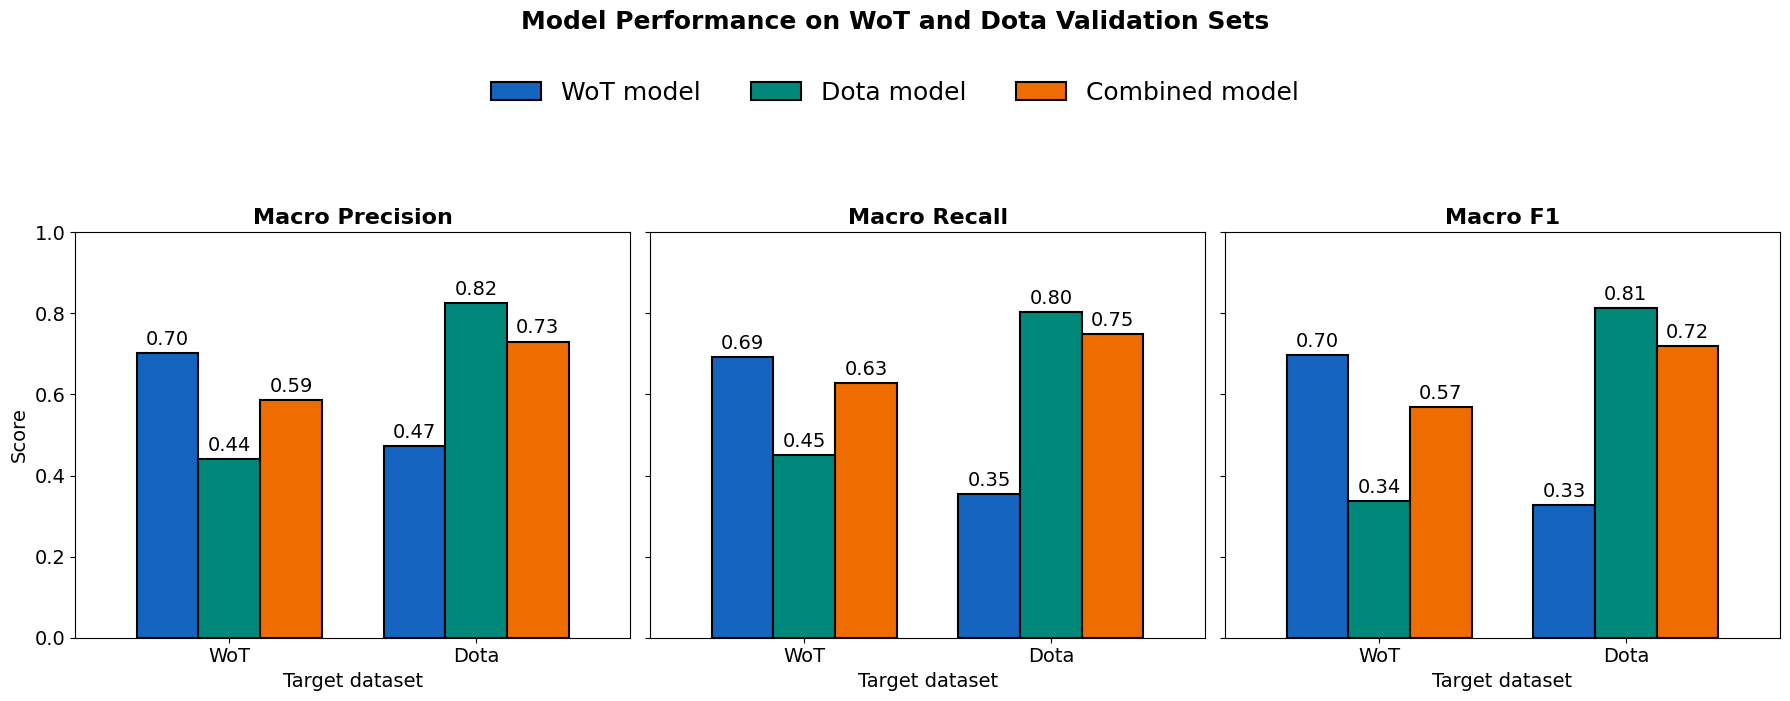

In [43]:
# performance comparison: single-game models vs combined model
# grouped by target dataset, with macro precision / recall / f1

combined_class_names = ['Non-Toxic', 'Mild Toxicity', 'Severe Toxicity']

def load_val_split(load_fn, scheme=None):
    df = load_fn('val').copy()
    if scheme is not None:
        df['label'] = df['label'].astype(int).map(scheme)
    return df['message'], df['label']

def collect_metrics(model_name, target_name, pipe, X, y, class_names):
    report = classification_report(
        y,
        pipe.predict(X),
        target_names=class_names,
        zero_division=0,
        output_dict=True
    )
    return {
        'Model': model_name,
        'Target': target_name,
        'Macro Precision': report['macro avg']['precision'],
        'Macro Recall': report['macro avg']['recall'],
        'Macro F1': report['macro avg']['f1-score'],
        'Weighted F1': report['weighted avg']['f1-score'],
    }

# validation splits
X_wot_val, y_wot_val = load_val_split(load_wot, WOT_SCHEME_3)
X_dota_val, y_dota_val = load_val_split(load_dota, DOTA_SCHEME_3)
X_comb_val, y_comb_val = load_val_split(load_combined_3class, scheme=None)

rows = [
    collect_metrics('WoT model', 'WoT', wot_best_pipe, X_wot_val, y_wot_val, WOT_CLASS_NAMES[3]),
    collect_metrics('WoT model', 'Dota', wot_best_pipe, X_dota_val, y_dota_val, DOTA_CLASS_NAMES[3]),
    collect_metrics('Dota model', 'WoT', dota_best_pipe, X_wot_val, y_wot_val, WOT_CLASS_NAMES[3]),
    collect_metrics('Dota model', 'Dota', dota_best_pipe, X_dota_val, y_dota_val, DOTA_CLASS_NAMES[3]),
    collect_metrics('Combined model', 'WoT', combined_best_pipe, X_wot_val, y_wot_val, WOT_CLASS_NAMES[3]),
    collect_metrics('Combined model', 'Dota', combined_best_pipe, X_dota_val, y_dota_val, DOTA_CLASS_NAMES[3]),
    collect_metrics('Combined model', 'Combined', combined_best_pipe, X_comb_val, y_comb_val, combined_class_names),
]

perf_df = pd.DataFrame(rows)

# nicer ordering
target_order = ['WoT', 'Dota', 'Combined']
model_order = ['WoT model', 'Dota model', 'Combined model']
perf_df['Target'] = pd.Categorical(perf_df['Target'], categories=target_order, ordered=True)
perf_df['Model'] = pd.Categorical(perf_df['Model'], categories=model_order, ordered=True)
perf_df = perf_df.sort_values(['Target', 'Model']).reset_index(drop=True)

display(perf_df.round(4))

# plot only comparable target datasets for grouped model comparison
plot_df = perf_df[perf_df['Target'].isin(['WoT', 'Dota'])].copy()

metrics = ['Macro Precision', 'Macro Recall', 'Macro F1']
colors = {
    'WoT model': '#1565C0',
    'Dota model': '#00897B',
    'Combined model': '#EF6C00',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, metric in zip(axes, metrics):
    pivot_df = plot_df.pivot(index='Target', columns='Model', values=metric)
    pivot_df = pivot_df[['WoT model', 'Dota model', 'Combined model']]

    pivot_df.plot(
        kind='bar',
        ax=ax,
        color=[colors[col] for col in pivot_df.columns],
        width=0.75, 
        edgecolor='black',
        linewidth=1.5,
    )

    ax.set_title(metric, fontweight='bold', fontsize = 16)
    ax.set_xlabel('Target dataset', fontsize = 14)
    ax.set_ylabel('Score', fontsize = 14)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=0, labelsize = 14)
    ax.tick_params(axis='y', labelsize = 14)

    # numbers on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=14)

    ax.legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),
    ncol=3,
    frameon=False,
    fontsize=18
)

fig.suptitle('Model Performance on WoT and Dota Validation Sets',
             fontweight='bold', y=1.16, fontsize = 18)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## Section 4: Interpretability

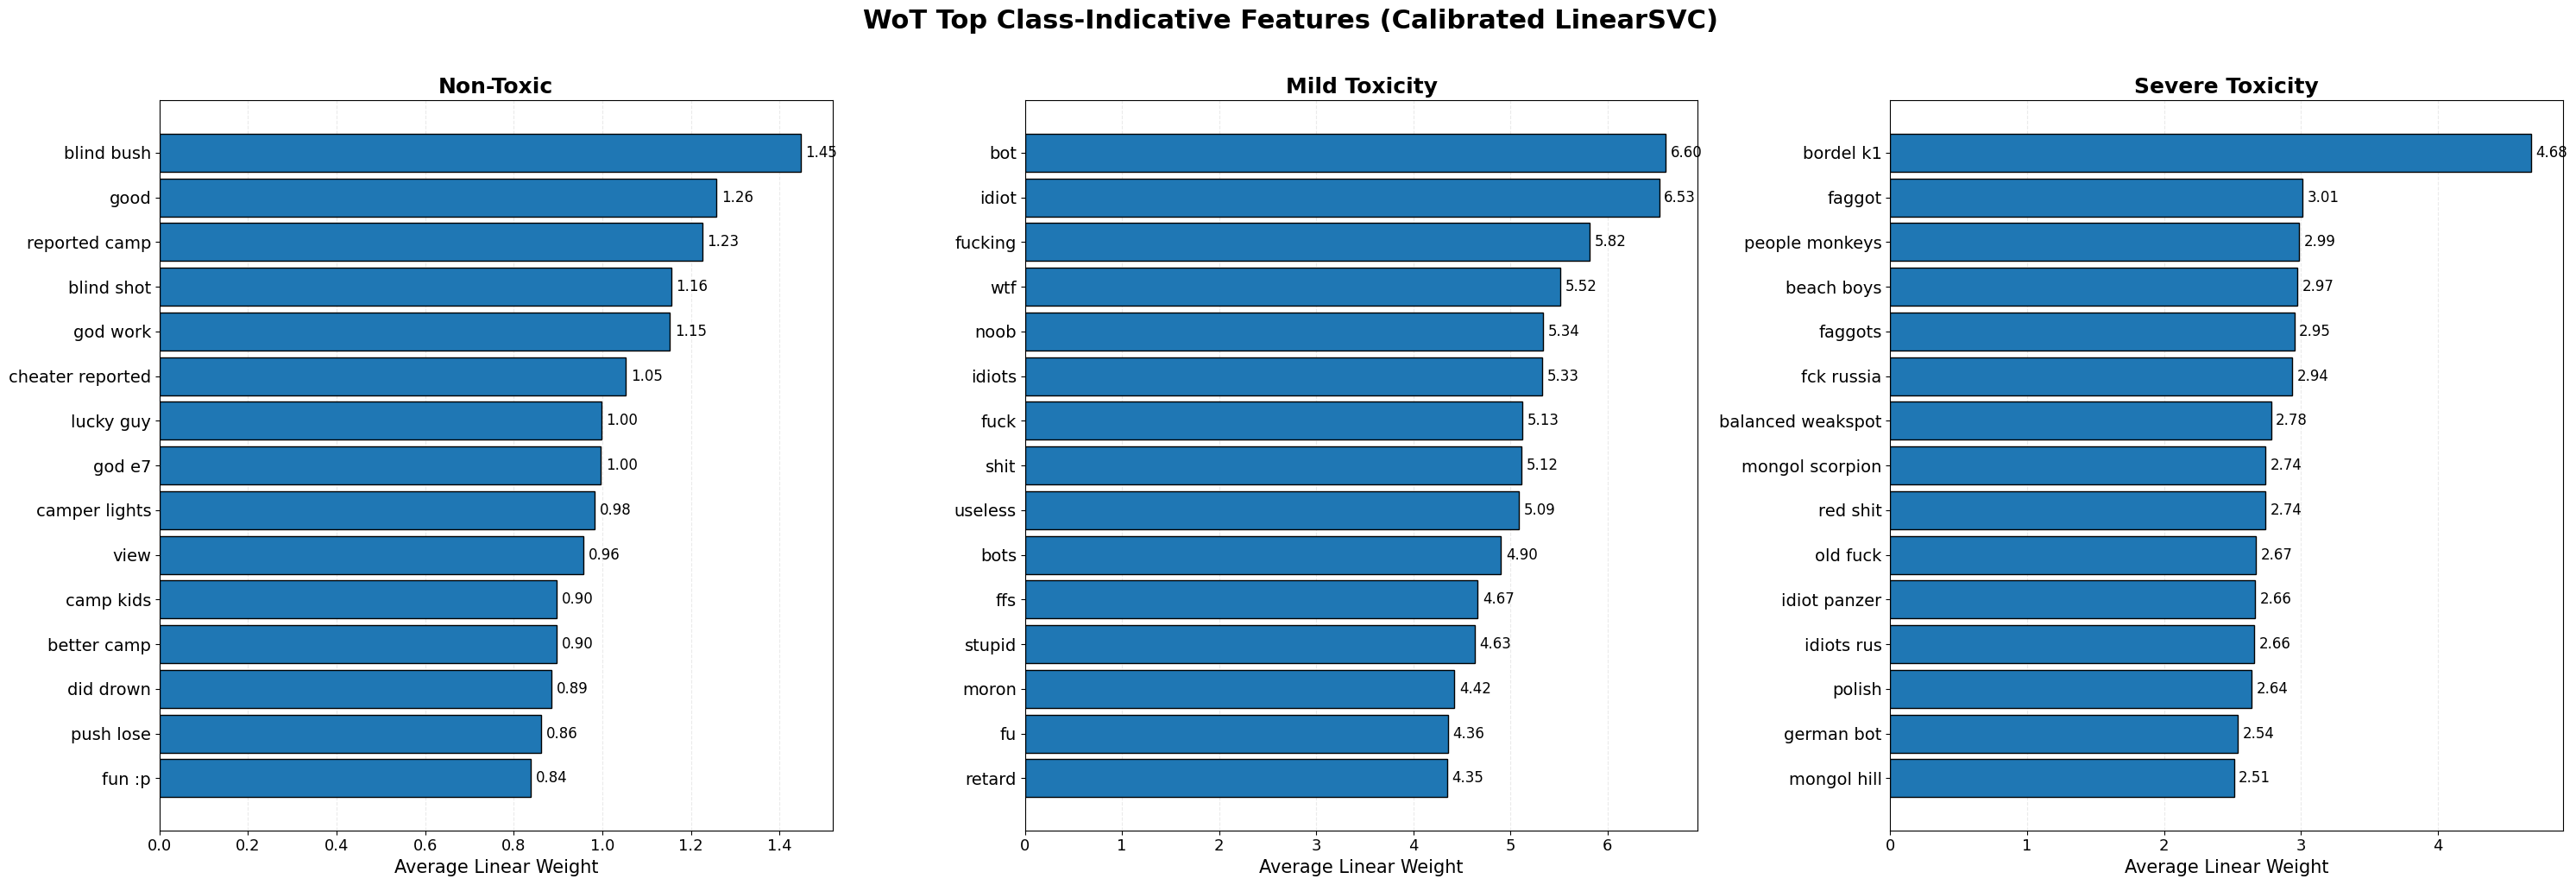

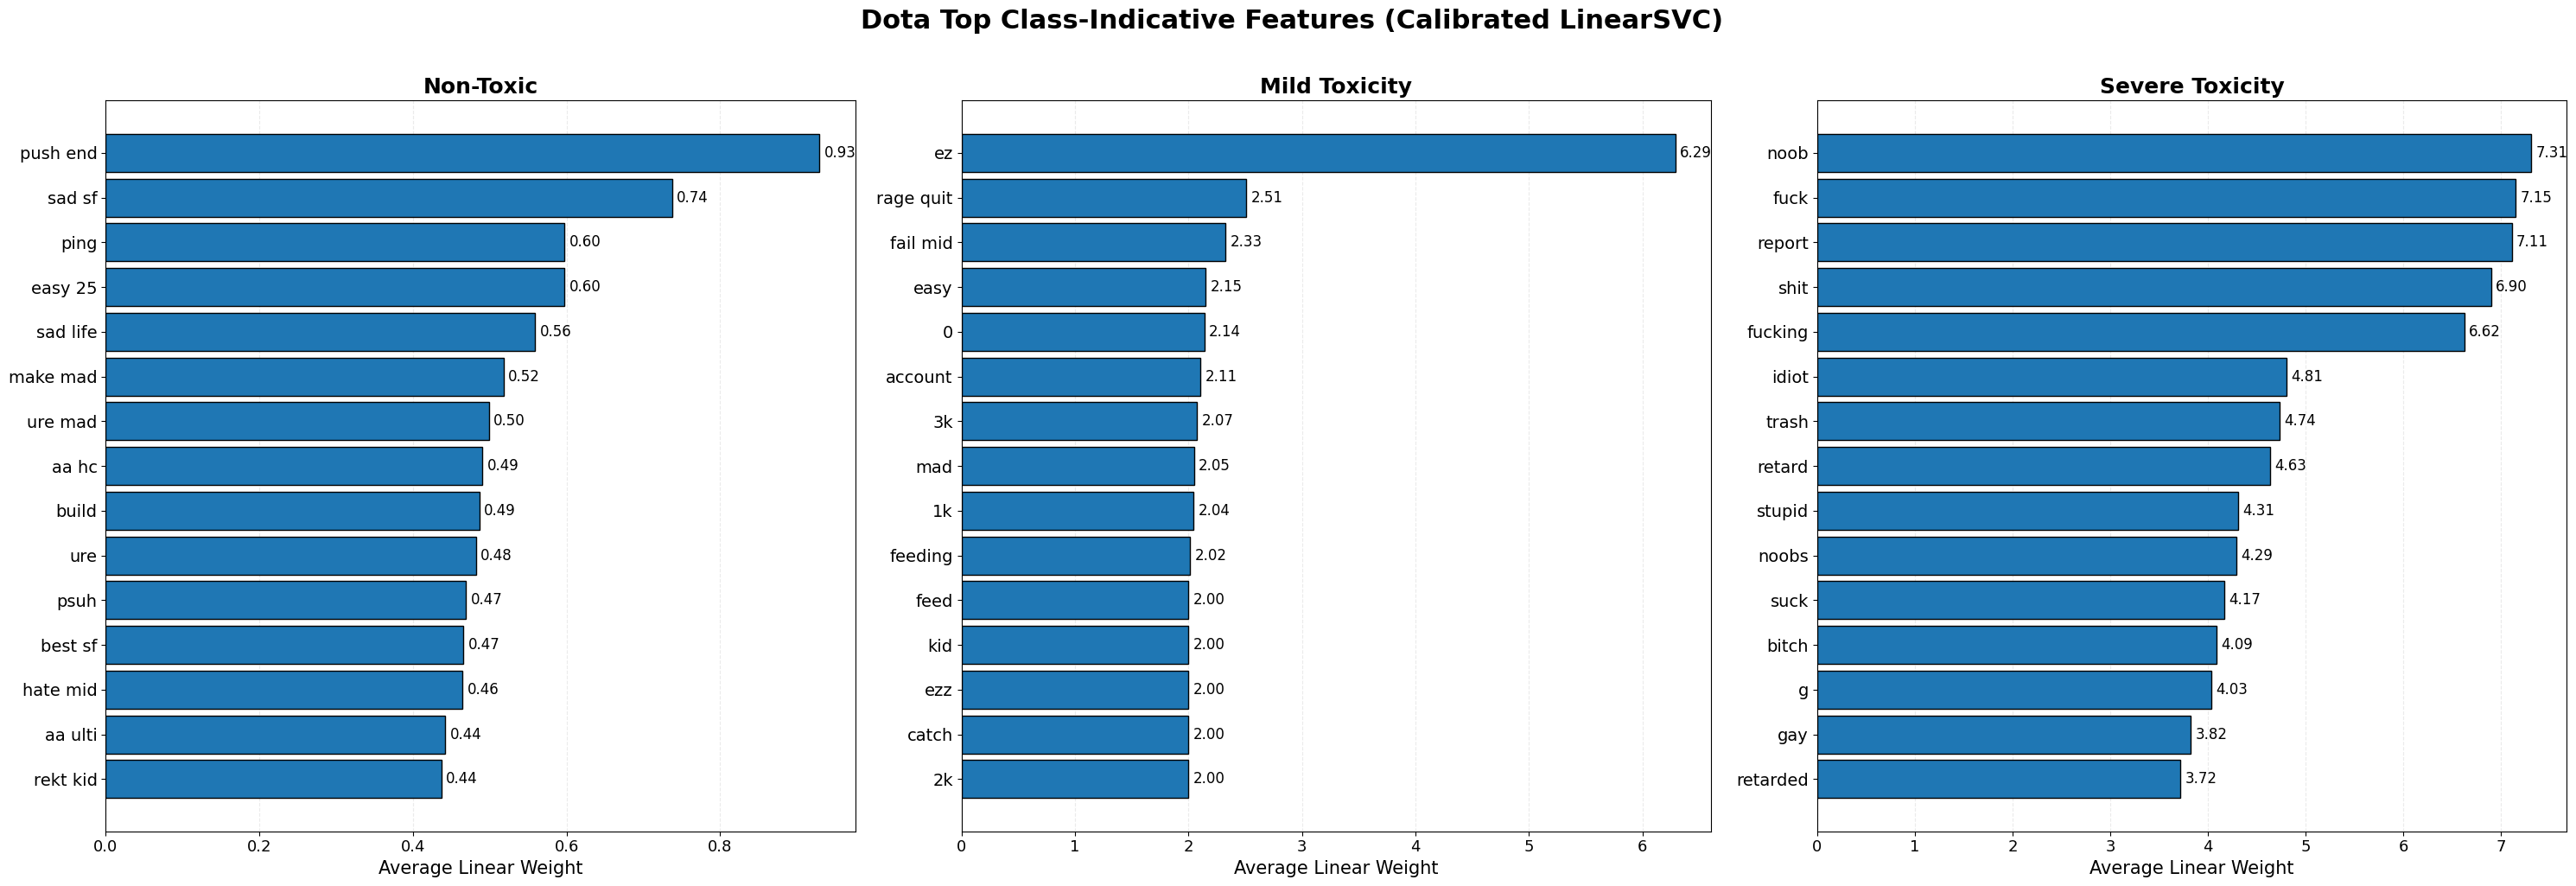

In [75]:
def plot_top_positive_features_all_classes_calibrated(pipe, class_names, title, top_n=15):
    clf = pipe.named_steps['clf']
    tfidf = pipe.named_steps['tfidf']
    feature_names = np.array(tfidf.get_feature_names_out())

    # average coefficients across calibrated folds
    coefs = np.mean(
        [cal.estimator.coef_ for cal in clf.calibrated_classifiers_],
        axis=0
    )  # shape: (n_classes, n_features)

    n_classes = len(class_names)
    fig, axes = plt.subplots(1, n_classes, figsize=(10 * n_classes, 10))
    if n_classes == 1:
        axes = [axes]

    for class_idx, ax in enumerate(axes):
        class_coef = coefs[class_idx]
        top_idx = np.argsort(class_coef)[-top_n:]

        vals = class_coef[top_idx]
        names = feature_names[top_idx]

        order = np.argsort(vals)
        vals = vals[order]
        names = names[order]

        bars = ax.barh(
            names,
            vals,
            color='#1f77b4',
            edgecolor='black',
            linewidth=1.0,
            height=0.85
        )

        ax.set_title(class_names[class_idx], fontweight='bold', fontsize=18)
        ax.set_xlabel('Average Linear Weight', fontsize=15)
        ax.tick_params(axis='y', labelsize=14)
        ax.tick_params(axis='x', labelsize=13)
        ax.grid(axis='x', linestyle='--', alpha=0.25)
        ax.set_axisbelow(True)

        ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=12)

    plt.suptitle(title, fontweight='bold', fontsize=22, y=1.02)
    plt.tight_layout()
    plt.show()

# WoT
plot_top_positive_features_all_classes_calibrated(
    wot_best_pipe_calibrated,
    WOT_CLASS_NAMES[wot_best_n],
    'WoT Top Class-Indicative Features (Calibrated LinearSVC)',
    top_n=15
)

# Dota
plot_top_positive_features_all_classes_calibrated(
    dota_best_pipe_calibrated,
    DOTA_CLASS_NAMES[dota_best_n],
    'Dota Top Class-Indicative Features (Calibrated LinearSVC)',
    top_n=15
)

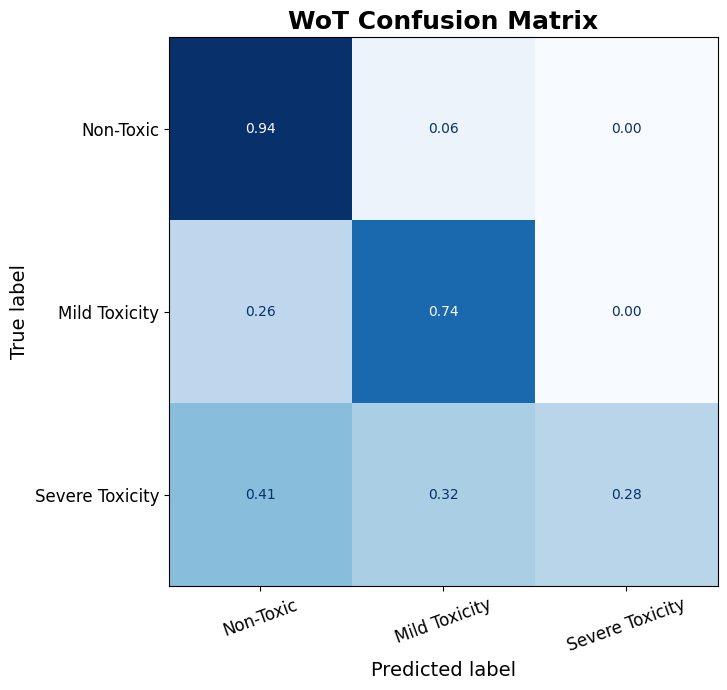

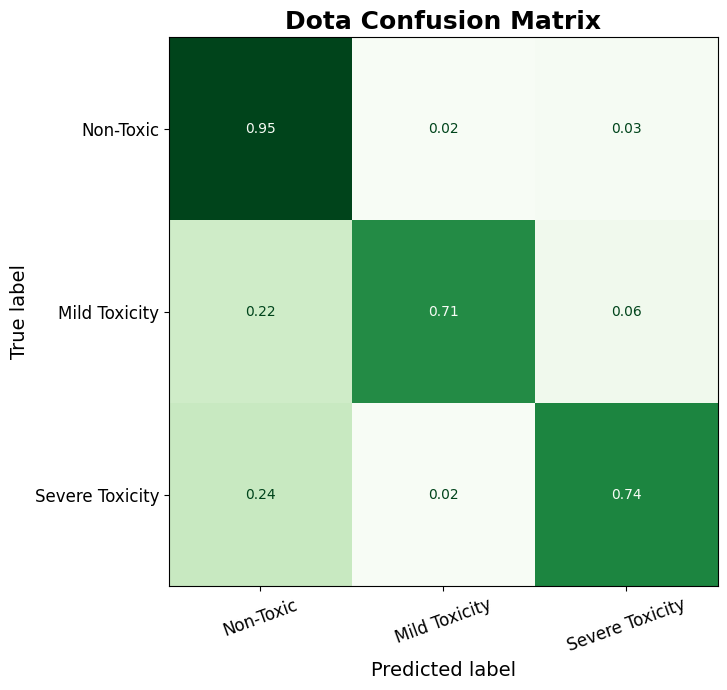

In [83]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix_for_pipe(pipe, load_fn, scheme, class_names, title, cmap='Blues'):
    val_df = load_fn('val').copy()
    if scheme is not None:
        val_df['label'] = val_df['label'].astype(int).map(scheme)

    X_val = val_df['message']
    y_val = val_df['label']

    y_pred = pipe.predict(X_val)
    cm = confusion_matrix(y_val, y_pred, labels=list(range(len(class_names))), 
                          normalize= 'true')

    fig, ax = plt.subplots(figsize=(8, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names, 
                                  )
    disp.plot(ax=ax, cmap=cmap, colorbar=False, values_format='.2f')

    ax.set_title(title, fontweight='bold', fontsize=18)
    ax.set_xlabel('Predicted label', fontsize=14)
    ax.set_ylabel('True label', fontsize=14)
    ax.tick_params(axis='x', labelrotation=20, labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    plt.tight_layout()
    plt.show()


# WoT
plot_confusion_matrix_for_pipe(
    wot_best_pipe_calibrated,
    load_wot,
    WOT_SCHEME_3,
    WOT_CLASS_NAMES[3],
    'WoT Confusion Matrix',
    cmap='Blues'
)

# Dota
plot_confusion_matrix_for_pipe(
    dota_best_pipe_calibrated,
    load_dota,
    DOTA_SCHEME_3,
    DOTA_CLASS_NAMES[3],
    'Dota Confusion Matrix',
    cmap='Greens'
)

In [92]:
def compare_model_correctness(y_true, pred_a, pred_b, name_a, name_b):
    a_correct = pred_a == y_true
    b_correct = pred_b == y_true

    return pd.Series({
        'both_correct': int((a_correct & b_correct).sum()),
        f'only_{name_a}_correct': int((a_correct & ~b_correct).sum()),
        f'only_{name_b}_correct': int((~a_correct & b_correct).sum()),
        'both_wrong': int((~a_correct & ~b_correct).sum()),
    })


def complementary_examples(df, y_true, pred_a, pred_b, name_a, name_b, class_names):
    out = df.copy().reset_index(drop=True)
    out['y_true'] = y_true
    out[f'pred_{name_a}'] = pred_a
    out[f'pred_{name_b}'] = pred_b

    out['true_label'] = out['y_true'].map(dict(enumerate(class_names)))
    out[f'{name_a}_label'] = out[f'pred_{name_a}'].map(dict(enumerate(class_names)))
    out[f'{name_b}_label'] = out[f'pred_{name_b}'].map(dict(enumerate(class_names)))

    only_a = out[(out['y_true'] == out[f'pred_{name_a}']) & (out['y_true'] != out[f'pred_{name_b}'])]
    only_b = out[(out['y_true'] != out[f'pred_{name_a}']) & (out['y_true'] == out[f'pred_{name_b}'])]

    return only_a, only_b


# WoT validation: what does Dota get right that WoT misses, and vice versa?
wot_val_df = load_wot('val').copy()
wot_val_df['label'] = wot_val_df['label'].astype(int).map(WOT_SCHEME_3)

X_wot_val = wot_val_df['message']
y_wot_val = wot_val_df['label'].values

wot_on_wot = wot_best_pipe.predict(X_wot_val)
dota_on_wot = dota_best_pipe.predict(X_wot_val)

wot_overlap = compare_model_correctness(
    y_wot_val, wot_on_wot, dota_on_wot, 'wot', 'dota'
)
display(wot_overlap.to_frame(name='WoT validation'))

wot_only_wot_correct, wot_only_dota_correct = complementary_examples(
    wot_val_df, y_wot_val, wot_on_wot, dota_on_wot,
    'wot', 'dota', WOT_CLASS_NAMES[3]
)

print('WoT examples only WoT gets right:')
display(wot_only_wot_correct[['message', 'true_label', 'wot_label', 'dota_label']].head(20))

print('WoT examples only Dota gets right:')
display(wot_only_dota_correct[['message', 'true_label', 'wot_label', 'dota_label']].head(20))


# Dota validation: what does WoT get right that Dota misses, and vice versa?
dota_val_df = load_dota('val').copy()
dota_val_df['label'] = dota_val_df['label'].astype(int).map(DOTA_SCHEME_3)

X_dota_val = dota_val_df['message']
y_dota_val = dota_val_df['label'].values

dota_on_dota = dota_best_pipe.predict(X_dota_val)
wot_on_dota = wot_best_pipe.predict(X_dota_val)

dota_overlap = compare_model_correctness(
    y_dota_val, dota_on_dota, wot_on_dota, 'dota', 'wot'
)
display(dota_overlap.to_frame(name='Dota validation'))

dota_only_dota_correct, dota_only_wot_correct = complementary_examples(
    dota_val_df, y_dota_val, dota_on_dota, wot_on_dota,
    'dota', 'wot', DOTA_CLASS_NAMES[3]
)

print('Dota examples only Dota gets right:')
display(dota_only_dota_correct[['message', 'true_label', 'dota_label', 'wot_label']].head(20))

print('Dota examples only WoT gets right:')
display(dota_only_wot_correct[['message', 'true_label', 'dota_label', 'wot_label']].head(20))


,WoT validation
both_correct,7349
only_wot_correct,1591
only_dota_correct,350
both_wrong,609


WoT examples only WoT gets right:


,message,true_label,wot_label,dota_label
1,idiots,Mild Toxicity,Mild Toxicity,Severe Toxicity
19,ji ro you donkey,Mild Toxicity,Mild Toxicity,Non-Toxic
20,sleep you,Mild Toxicity,Mild Toxicity,Non-Toxic
22,fucking piss stain fv,Mild Toxicity,Mild Toxicity,Severe Toxicity
32,FOR FUCKS SAKES!,Mild Toxicity,Mild Toxicity,Severe Toxicity
34,fuck you ALL noobs,Mild Toxicity,Mild Toxicity,Severe Toxicity
39,mrs idiote,Mild Toxicity,Mild Toxicity,Non-Toxic
40,i have 2k spot damage,Non-Toxic,Non-Toxic,Mild Toxicity
47,fucking team,Mild Toxicity,Mild Toxicity,Severe Toxicity
48,useless shits,Mild Toxicity,Mild Toxicity,Severe Toxicity


WoT examples only Dota gets right:


,message,true_label,wot_label,dota_label
2,yea this kick hard,Non-Toxic,Mild Toxicity,Non-Toxic
6,iam total happy,Non-Toxic,Mild Toxicity,Non-Toxic
44,ebr go play lego,Non-Toxic,Mild Toxicity,Non-Toxic
83,No time for camping,Non-Toxic,Mild Toxicity,Non-Toxic
85,wtf,Non-Toxic,Mild Toxicity,Non-Toxic
91,NEXT BIG COWARDS DODGER !!!!!!!!!!!!!!!!!!!!!!...,Non-Toxic,Mild Toxicity,Non-Toxic
133,704 bot,Non-Toxic,Mild Toxicity,Non-Toxic
142,now enjoy,Non-Toxic,Mild Toxicity,Non-Toxic
180,camping all game,Non-Toxic,Mild Toxicity,Non-Toxic
181,you talk to much,Non-Toxic,Mild Toxicity,Non-Toxic


,Dota validation
both_correct,4787
only_dota_correct,1610
only_wot_correct,195
both_wrong,565


Dota examples only Dota gets right:


,message,true_label,dota_label,wot_label
0,wtf,Non-Toxic,Non-Toxic,Mild Toxicity
3,who knows i muted him fuckin trash,Severe Toxicity,Severe Toxicity,Mild Toxicity
11,wtf,Non-Toxic,Non-Toxic,Mild Toxicity
17,yeah fuck this random scum huskar report the f...,Severe Toxicity,Severe Toxicity,Mild Toxicity
20,"lol, we playing even am part",Non-Toxic,Non-Toxic,Mild Toxicity
22,ez mmr qop,Mild Toxicity,Mild Toxicity,Non-Toxic
27,moron they waited u itde,Severe Toxicity,Severe Toxicity,Mild Toxicity
29,im just 12 years old,Non-Toxic,Non-Toxic,Mild Toxicity
31,pudge smoke in 1k mmr are you a fuckimg joke,Severe Toxicity,Severe Toxicity,Mild Toxicity
42,get this slark into ur team 6k moron,Severe Toxicity,Severe Toxicity,Mild Toxicity


Dota examples only WoT gets right:


,message,true_label,dota_label,wot_label
16,wtf this is us,Mild Toxicity,Non-Toxic,Mild Toxicity
41,wtf pudge,Mild Toxicity,Non-Toxic,Mild Toxicity
141,easy gg,Non-Toxic,Mild Toxicity,Non-Toxic
142,love beating peruvians in the morning,Non-Toxic,Severe Toxicity,Non-Toxic
213,wtf 4-12 i'll count sum mo la,Mild Toxicity,Severe Toxicity,Mild Toxicity
227,online,Non-Toxic,Severe Toxicity,Non-Toxic
232,20 deaths mmr leader,Non-Toxic,Mild Toxicity,Non-Toxic
252,how to push,Non-Toxic,Severe Toxicity,Non-Toxic
292,whole game 0 léti he thinsk he did,Non-Toxic,Mild Toxicity,Non-Toxic
299,fail doom,Mild Toxicity,Non-Toxic,Mild Toxicity


In [96]:
def summarize_complementarity_vs_full_class(df_subset, full_df, true_label_col='true_label'):
    subset_counts = df_subset[true_label_col].value_counts()
    full_counts = full_df[true_label_col].value_counts()

    classes = full_counts.index
    out = pd.DataFrame({
        'True class': classes,
        'Subset count': [subset_counts.get(c, 0) for c in classes],
        'Full class count': [full_counts.get(c, 0) for c in classes],
    })

    out['Percent of full class'] = (
        out['Subset count'] / out['Full class count'] * 100
    ).round(2)

    return out


# make sure these exist
wot_val_df_labels = wot_val_df.copy()
wot_val_df_labels['true_label'] = wot_val_df_labels['label'].map(dict(enumerate(WOT_CLASS_NAMES[3])))

dota_val_df_labels = dota_val_df.copy()
dota_val_df_labels['true_label'] = dota_val_df_labels['label'].map(dict(enumerate(DOTA_CLASS_NAMES[3])))

print('WoT: only Dota gets right, as % of each WoT true class')
display(summarize_complementarity_vs_full_class(
    wot_only_dota_correct,
    wot_val_df_labels,
    true_label_col='true_label'
))

print('WoT: only WoT gets right, as % of each WoT true class')
display(summarize_complementarity_vs_full_class(
    wot_only_wot_correct,
    wot_val_df_labels,
    true_label_col='true_label'
))

print('Dota: only WoT gets right, as % of each Dota true class')
display(summarize_complementarity_vs_full_class(
    dota_only_wot_correct,
    dota_val_df_labels,
    true_label_col='true_label'
))

print('Dota: only Dota gets right, as % of each Dota true class')
display(summarize_complementarity_vs_full_class(
    dota_only_dota_correct,
    dota_val_df_labels,
    true_label_col='true_label'
))



WoT: only Dota gets right, as % of each WoT true class


,True class,Subset count,Full class count,Percent of full class
0,Non-Toxic,314,8050,3.90
1,Mild Toxicity,23,1780,1.29
2,Severe Toxicity,13,69,18.84


WoT: only WoT gets right, as % of each WoT true class


,True class,Subset count,Full class count,Percent of full class
0,Non-Toxic,320,8050,3.98
1,Mild Toxicity,1256,1780,70.56
2,Severe Toxicity,15,69,21.74


Dota: only WoT gets right, as % of each Dota true class


,True class,Subset count,Full class count,Percent of full class
0,Non-Toxic,160,5301,3.02
1,Severe Toxicity,4,1404,0.28
2,Mild Toxicity,31,452,6.86


Dota: only Dota gets right, as % of each Dota true class


,True class,Subset count,Full class count,Percent of full class
0,Non-Toxic,299,5301,5.64
1,Severe Toxicity,1002,1404,71.37
2,Mild Toxicity,309,452,68.36


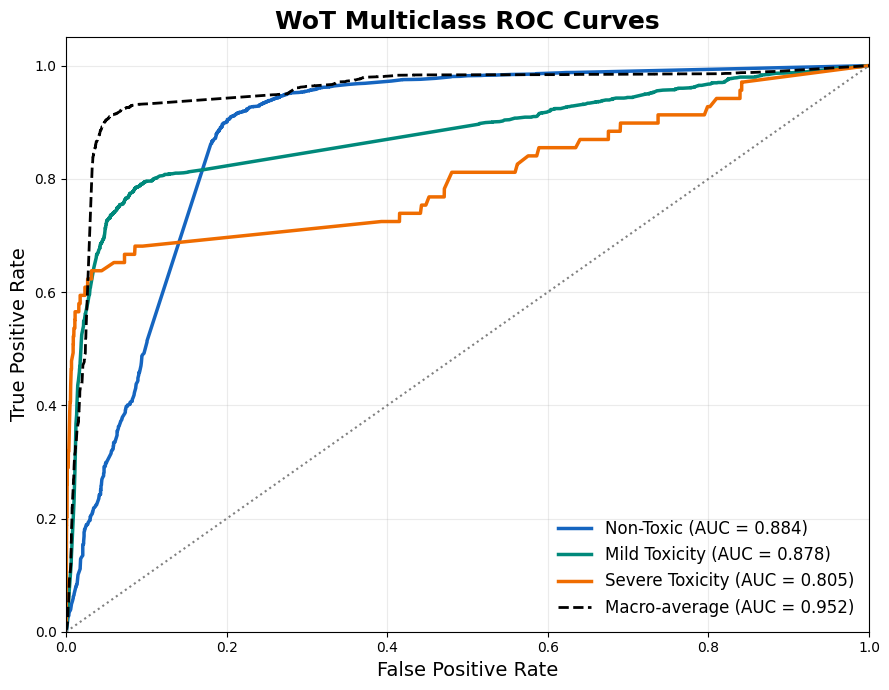

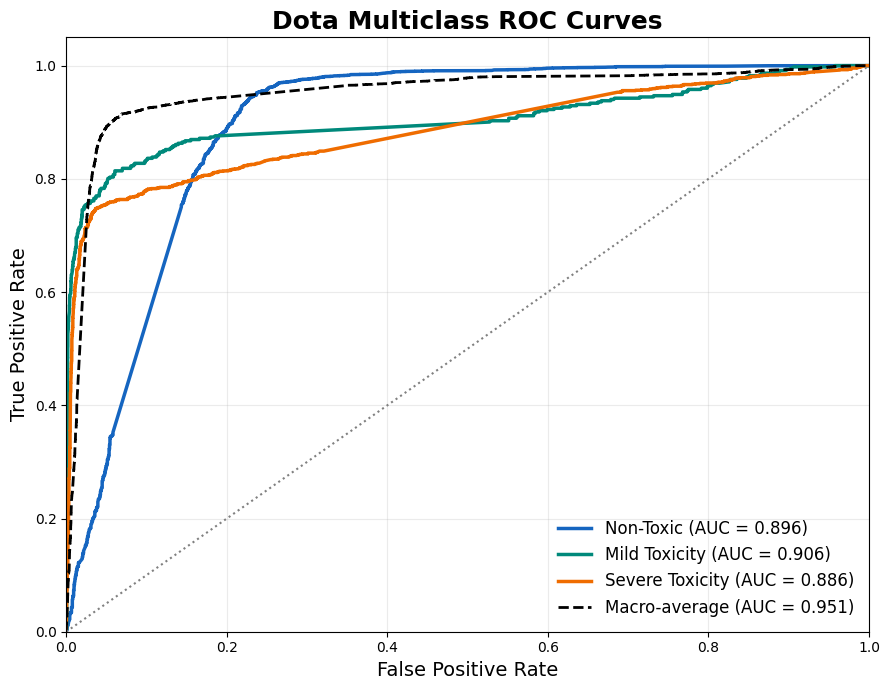

In [86]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_multiclass_roc(pipe, load_fn, scheme, class_names, title):
    val_df = load_fn('val').copy()
    if scheme is not None:
        val_df['label'] = val_df['label'].astype(int).map(scheme)

    X_val = val_df['message']
    y_val = val_df['label'].values

    n_classes = len(class_names)
    y_bin = label_binarize(y_val, classes=list(range(n_classes)))

    # calibrated models: probabilities
    if hasattr(pipe, "predict_proba"):
        y_score = pipe.predict_proba(X_val)
    else:
        # fallback for plain LinearSVC
        y_score = pipe.decision_function(X_val)

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # macro-average
    fpr["macro"], tpr["macro"], _ = roc_curve(y_bin.ravel(), y_score.ravel())
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    plt.figure(figsize=(9, 7))

    colors = ['#1565C0', '#00897B', '#EF6C00']
    for i, color in zip(range(n_classes), colors):
        plt.plot(
            fpr[i],
            tpr[i],
            color=color,
            lw=2.5,
            label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})'
        )

    plt.plot(
        fpr["macro"],
        tpr["macro"],
        color='black',
        linestyle='--',
        lw=2,
        label=f'Macro-average (AUC = {roc_auc["macro"]:.3f})'
    )

    plt.plot([0, 1], [0, 1], color='gray', linestyle=':', lw=1.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate', fontsize=14)
    plt.title(title, fontweight='bold', fontsize=18)
    plt.legend(loc='lower right', fontsize=12, frameon=False)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    return roc_auc

# wot
wot_roc_auc = plot_multiclass_roc(
    wot_best_pipe_calibrated,
    load_wot,
    WOT_SCHEME_3,
    WOT_CLASS_NAMES[3],
    'WoT Multiclass ROC Curves'
)

# dota
dota_roc_auc = plot_multiclass_roc(
    dota_best_pipe_calibrated,
    load_dota,
    DOTA_SCHEME_3,
    DOTA_CLASS_NAMES[3],
    'Dota Multiclass ROC Curves'
)

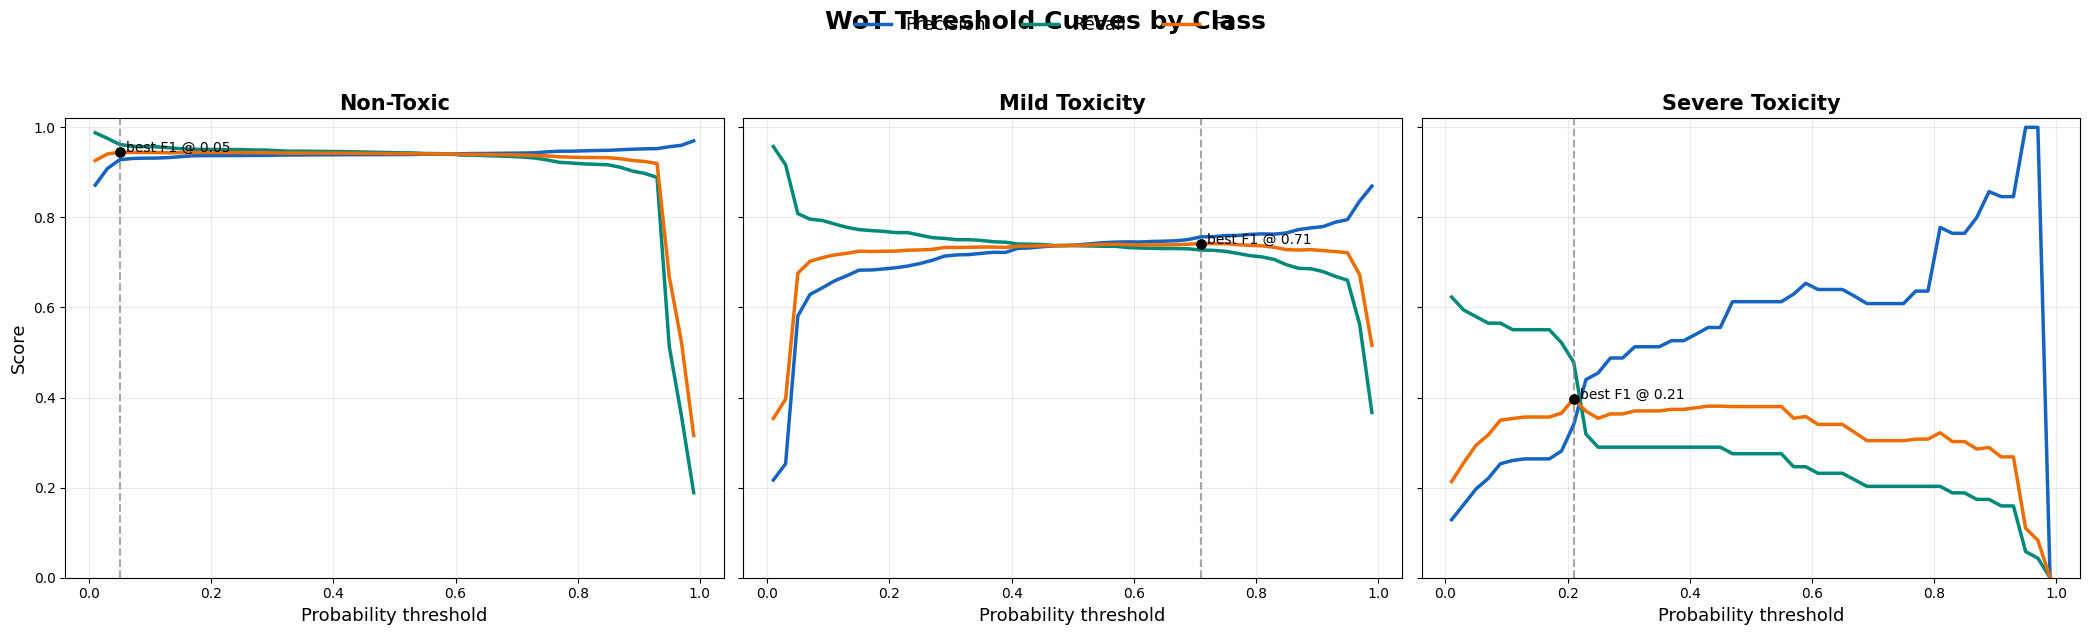

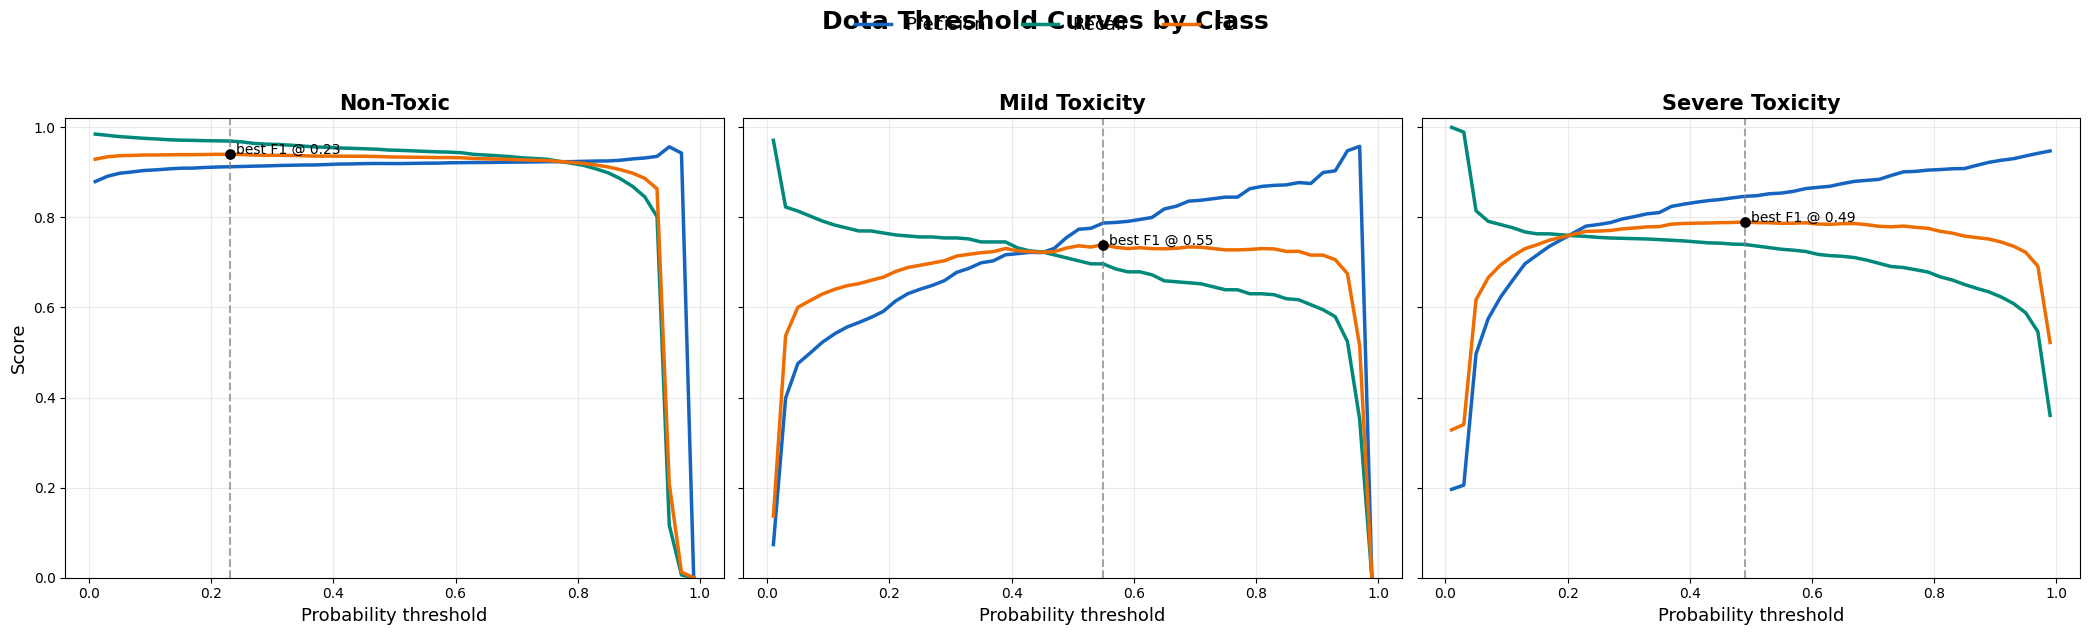

In [102]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_score, recall_score, f1_score

def plot_threshold_metrics_by_class(pipe, load_fn, scheme, class_names, thresholds=None, title_prefix=''):
    if not hasattr(pipe, 'predict_proba'):
        raise ValueError('This plot expects a calibrated model with predict_proba().')

    val_df = load_fn('val').copy()
    if scheme is not None:
        val_df['label'] = val_df['label'].astype(int).map(scheme)

    X_val = val_df['message']
    y_val = val_df['label'].values

    n_classes = len(class_names)
    y_bin = label_binarize(y_val, classes=list(range(n_classes)))
    probs = pipe.predict_proba(X_val)

    if thresholds is None:
        thresholds = np.round(np.arange(0.01, 1.00, 0.02), 2)

    fig, axes = plt.subplots(1, n_classes, figsize=(7 * n_classes, 6), sharey=True)
    if n_classes == 1:
        axes = [axes]

    all_tables = []

    for class_idx, ax in enumerate(axes):
        y_true = y_bin[:, class_idx]
        y_score = probs[:, class_idx]

        rows = []
        for thr in thresholds:
            y_pred_bin = (y_score >= thr).astype(int)
            rows.append({
                'Class': class_names[class_idx],
                'Threshold': thr,
                'Precision': precision_score(y_true, y_pred_bin, zero_division=0),
                'Recall': recall_score(y_true, y_pred_bin, zero_division=0),
                'F1': f1_score(y_true, y_pred_bin, zero_division=0),
                'Predicted Positive Rate': y_pred_bin.mean(),
            })

        class_df = pd.DataFrame(rows)
        all_tables.append(class_df)

        ax.plot(class_df['Threshold'], class_df['Precision'], label='Precision', linewidth=2.5, color='#1565C0')
        ax.plot(class_df['Threshold'], class_df['Recall'], label='Recall', linewidth=2.5, color='#00897B')
        ax.plot(class_df['Threshold'], class_df['F1'], label='F1', linewidth=2.5, color='#EF6C00')

        best_idx = class_df['F1'].idxmax()
        best_thr = class_df.loc[best_idx, 'Threshold']
        best_f1 = class_df.loc[best_idx, 'F1']

        ax.axvline(best_thr, color='gray', linestyle='--', alpha=0.7)
        ax.scatter(best_thr, best_f1, color='black', s=45, zorder=5)
        ax.text(best_thr + 0.01, best_f1, f'best F1 @ {best_thr:.2f}', fontsize=10)

        ax.set_title(class_names[class_idx], fontweight='bold', fontsize=15)
        ax.set_xlabel('Probability threshold', fontsize=13)
        ax.set_ylim(0, 1.02)
        ax.grid(alpha=0.25)

    axes[0].set_ylabel('Score', fontsize=13)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False, fontsize=13)
    fig.suptitle(f'{title_prefix} Threshold Curves by Class', fontweight='bold', fontsize=18, y=1.05)

    plt.tight_layout()
    plt.show()

    return pd.concat(all_tables, ignore_index=True)

wot_threshold_curves = plot_threshold_metrics_by_class(
    wot_best_pipe_calibrated,
    load_wot,
    WOT_SCHEME_3,
    WOT_CLASS_NAMES[3],
    title_prefix='WoT'
)

dota_threshold_curves = plot_threshold_metrics_by_class(
    dota_best_pipe_calibrated,
    load_dota,
    DOTA_SCHEME_3,
    DOTA_CLASS_NAMES[3],
    title_prefix='Dota'
)
